# Lane Agent Runner

이 노트북은 MMS LAS 차선 탐지 에이전트를 **주피터 노트북에서 바로 실행**하기 위한 파일입니다.

실행 순서:
1. 아래 설치 셀 실행
2. `PROJECT_ROOT`, `LAS_PATH`, `P0`, `P1`, `OUTPUT_CSV` 수정
3. 전체 실행


In [28]:
# 필요 패키지 설치
# 처음 한 번만 실행하면 됩니다.
# %pip install -q numpy laspy matplotlib


In [29]:
from pathlib import Path
import sys
import json
import numpy as np
import importlib
import lane_agent.agent
importlib.reload(lane_agent.agent)

# 프로젝트 루트 경로
# 1) 노트북을 lane_agent_project 폴더 안에 복사해서 열면 Path.cwd() 사용
# 2) 아니면 아래처럼 직접 경로 지정
PROJECT_ROOT = Path.cwd()
# PROJECT_ROOT = Path(r"D:/your_folder/lane_agent_project")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print('PROJECT_ROOT =', PROJECT_ROOT)


PROJECT_ROOT = d:\Conda_envs\lane_tracker\lane_agent_project


In [ ]:
# 실행 파라미터 설정
CONFIG_PATH = PROJECT_ROOT / 'config.yaml'

# 라이다 데이터 패스 / 시작점 / 방향점 
LAS_PATH = PROJECT_ROOT / 'data' / '5959_202504030857_S02_01.las' 
P0 = np.array([314463.621002, 3899692.699001, 74.064003], dtype=np.float64)
P1 = np.array([314460.868988, 3899692.244999, 74.109001], dtype=np.float64)
OUTPUT_CSV = PROJECT_ROOT / '5959_202504030857_S02_01.csv'

# LAS_PATH = PROJECT_ROOT / 'data' / '5959_202404040949_Track01_1.las' 
# P0 = np.array([332288.257999,4220710.7685,102.856498718], dtype=np.float64)
# P1 = np.array([332288.030002,4220710.9235,102.82849884], dtype=np.float64)
# OUTPUT_CSV = PROJECT_ROOT / '5959_202404040949_Track01_1_1.csv'

# LAS_PATH = PROJECT_ROOT / 'data' / '5959_202404040949_Track01_1.las' 
# P0 = np.array([332252.987001,4220738.4775,100.026496887], dtype=np.float64)
# P1 = np.array([332252.837001,4220738.9085,100.01650238 ], dtype=np.float64)
# OUTPUT_CSV = PROJECT_ROOT / '5959_202404040949_Track01_1_2.csv'

print('LAS_PATH   =', LAS_PATH)
print('CONFIG_PATH=', CONFIG_PATH)
print('OUTPUT_CSV =', OUTPUT_CSV)
print('P0 =', P0)
print('P1 =', P1)


LAS_PATH   = d:\Conda_envs\lane_tracker\lane_agent_project\data\5959_202404040949_Track01_1.las
CONFIG_PATH= d:\Conda_envs\lane_tracker\lane_agent_project\config.yaml
OUTPUT_CSV = d:\Conda_envs\lane_tracker\lane_agent_project\5959_202404040949_Track01_1_2.csv
P0 = [3.32252987e+05 4.22073848e+06 1.00026497e+02]
P1 = [3.32252837e+05 4.22073891e+06 1.00016502e+02]


In [31]:
# 모듈 import
from lane_agent.config import load_config
from lane_agent.las_io import load_las_xyz_intensity
from lane_agent.agent import LaneTrackerAgent
from lane_agent.csv_io import save_xyz_csv


In [32]:
# 설정 / LAS 로드
cfg = load_config(CONFIG_PATH)
las = load_las_xyz_intensity(str(LAS_PATH))

print('num_points =', las.xyz.shape[0])
print('xyz shape  =', las.xyz.shape)
print('intensity shape =', las.intensity.shape)
print('config =', cfg)


num_points = 6384772
xyz shape  = (6384772, 3)
intensity shape = (6384772,)
config = {'max_track_length_m': 500.0, 'step_m': 0.3, 'search_half_width_m': 0.6, 'search_forward_samples': 5, 'search_lateral_samples': 9, 'search_radius_m': 0.18, 'max_gap_m': 4.5, 'min_score': 0.32, 'grid_size_m': 0.22, 'seed_profile_radius_m': 0.35, 'intensity_window_quantile_low': 0.55, 'intensity_window_quantile_high': 0.98, 'straight_bias_weight': 0.3, 'continuity_weight': 0.25, 'contrast_weight': 0.2, 'intensity_weight': 0.25, 'max_heading_change_deg': 5.0, 'z_tolerance_m': 0.45, 'max_z_step_m': 0.12, 'z_fit_window_m': 0.18, 'hard_max_z_step_m': 0.14, 'center_offset_tolerance_m': 0.12, 'center_pull_weight': 0.9, 'hard_center_offset_limit_m': 0.18, 'center_refine_radius_m': 0.05, 'center_refine_max_shift_m': 0.03, 'lane_half_width_m': 0.09, 'cross_section_radius_m': 0.22, 'cross_section_forward_window_m': 0.1, 'cross_section_bin_size_m': 0.02, 'cross_section_stripe_threshold_ratio': 0.35, 'cross_section_

In [33]:
# 에이전트 실행
agent = LaneTrackerAgent(las.xyz, las.intensity, cfg)
debug_path = OUTPUT_CSV.with_suffix(OUTPUT_CSV.suffix + '.debug.json')

result = agent.track(P0, P1, str(debug_path))
from pathlib import Path
output_path = Path(OUTPUT_CSV)
post_output_path = output_path.with_name(f"{output_path.stem}_pc{output_path.suffix}")
save_xyz_csv(output_path, result.raw_points)
save_xyz_csv(post_output_path, result.points)

print('Saved CSV    :', OUTPUT_CSV)
print('Saved debug  :', debug_path)
print('Stop reason  :', result.stop_reason)
print('Saved raw CSV :', output_path)
print('Saved post CSV:', post_output_path)
print('Num lane pts :', result.points.shape[0])


Saved CSV    : d:\Conda_envs\lane_tracker\lane_agent_project\5959_202404040949_Track01_1_2.csv
Saved debug  : d:\Conda_envs\lane_tracker\lane_agent_project\5959_202404040949_Track01_1_2.csv.debug.json
Stop reason  : score_below_threshold
Saved raw CSV : d:\Conda_envs\lane_tracker\lane_agent_project\5959_202404040949_Track01_1_2.csv
Saved post CSV: d:\Conda_envs\lane_tracker\lane_agent_project\5959_202404040949_Track01_1_2_pc.csv
Num lane pts : 171


In [34]:
# 결과 미리보기
import csv

rows = []
with open(OUTPUT_CSV, 'r', encoding='utf-8') as f:
    reader = csv.reader(f)
    for i, row in enumerate(reader):
        rows.append(row)
        if i >= 10:
            break

for row in rows:
    print(row)


['x', 'y', 'z']
['332252.987001', '4220738.477500', '100.024500']
['332252.882648', '4220738.758755', '100.014500']
['332252.782214', '4220739.041475', '100.004500']
['332252.666747', '4220739.318748', '99.994500']
['332252.551001', '4220739.595647', '99.986500']
['332252.443151', '4220739.875603', '99.976500']
['332252.320874', '4220740.149896', '99.965500']
['332252.193950', '4220740.422109', '99.957500']
['332252.078240', '4220740.698913', '99.948500']
['332251.947900', '4220740.969437', '99.938500']


In [35]:
# 디버그 정보 일부 보기
if debug_path.exists():
    dbg = json.loads(debug_path.read_text(encoding='utf-8'))
    print('stop_reason =', dbg.get('stop_reason'))
    print('num_points   =', dbg.get('num_points'))
    print('num_steps    =', len(dbg.get('steps', [])))
    if dbg.get('steps'):
        print('first step keys =', dbg['steps'][0].keys())
else:
    print('debug file not found')


debug file not found


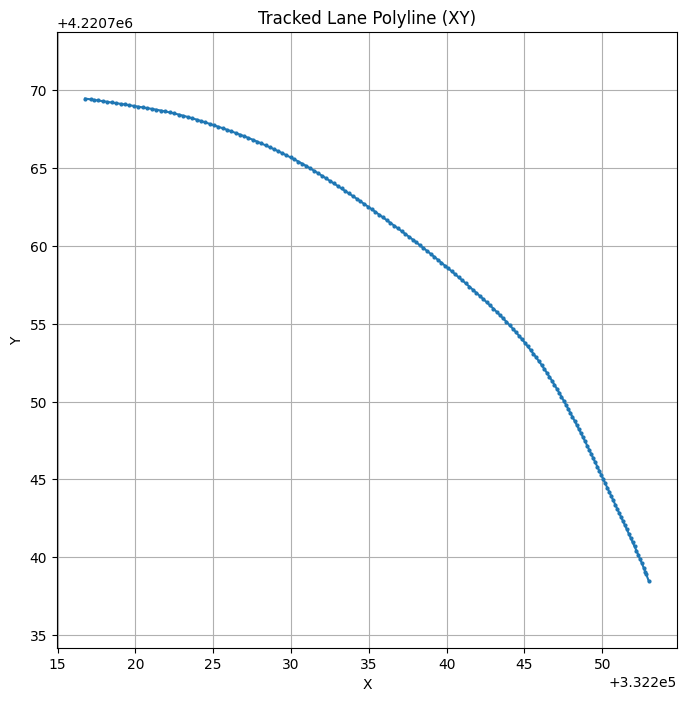

In [36]:
# 간단한 2D 시각화 (XY)
import matplotlib.pyplot as plt

if result.points.shape[0] > 0:
    plt.figure(figsize=(8, 8))
    plt.plot(result.points[:, 0], result.points[:, 1], marker='o', markersize=2)
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title('Tracked Lane Polyline (XY)')
    plt.axis('equal')
    plt.grid(True)
    plt.show()
else:
    print('No tracked points.')
